# Multi-Modal Ligand-Receptor Inference

This notebook shows how to 1. analyse single-cell cite-seq data; 2. how to infer metabolite-receptor interactions from transcriptomics data.

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import liana as li
import mudata as mu
from matplotlib import pyplot as plt

## Metabolite-mediated CCC from Transcriptomics Data

Recently, tools such as [NeuronChat](https://www.nature.com/articles/s41467-023-36800-w), [MEBOCOST](https://www.biorxiv.org/content/10.1101/2022.05.30.494067v2.abstract), [scConnect](https://academic.oup.com/bioinformatics/article/37/20/3501/6273571), [Cellinker](https://academic.oup.com/bioinformatics/article/37/14/2025/6104823), and [CellPhoneDBv5](https://arxiv.org/abs/2311.04567) have proposed approaches, such as enrichment, expression average, among others, to infer metabolite-mediated CCC events from transcriptomics data. Similarly, we can use LIANA+ to infer metabolite-mediated CCC events from transcriptomics data, as [described in the MetalinksDB manuscript](https://academic.oup.com/bib/article/25/4/bbae347/7717953).

Briefly, we use a univariate linear regression model to estimate metabolite abundances for each cell. To do so, we make use of production-degradation enzyme prior knowledge to infer the metabolite abundances. Optionally, we also take transporters into account. We then use these inferred metabolite abundances to infer metabolite-mediated CCC events.

<img src="../_static/metalinks_score.png" width=1000 />

### Focus on Transcriptomics Data

In [2]:
pwd

'/Users/ef6/Documents/GitHub/EBISystemsBioWorkshop26/2_metabolite_estimation'

In [ ]:
adata = sc.read_h5ad("../data/citeseq_rna.h5ad")

### Obtain MetalinksDB Prior Knowledge

Here, we will use MetalinksDB which contains prior knowledge about metabolite-receptor interactions as well as such for the production and degradation enzymes for metabolites. We will use the latter type of prior knowledge to infer the metabolite abundances for each cell.

In [4]:
import liana.resource as res
print(res.__dict__.get('METALINKS_DB'))

None


In [5]:
metalinks = li.resource.get_metalinks(biospecimen_location='Blood',
                                      source=['CellPhoneDB', 'Cellinker', 'scConnect', # Ligand-Receptor resources
                                              'recon', 'hmr', 'rhea', 'hmdb' # Production-Degradation resources
                                              ],
                                      types=['pd', 'lr'], # NOTE: we obtain both ligand-receptor and production-degradation sets
                                     )

### Prepare the Metabolite-Receptor Resource

In [6]:
resource = metalinks[metalinks['type']=='lr'].copy()
resource = resource[['metabolite', 'gene_symbol']]\
    .rename(columns={'gene_symbol':'receptor'}).drop_duplicates()
resource.head()

,metabolite,receptor
173,Oxoglutaric acid,OXGR1
351,Acetaldehyde,TRPA1
410,Calcitriol,VDR
843,ADP,P2RY1
1071,ADP,P2RY6


### Prepare the Production-Degradation Network

In [7]:
pd_net = metalinks[metalinks['type'] == 'pd']
# we need to aggregate the production-degradation values
pd_net = pd_net[['metabolite', 'gene_symbol', 'mor']].groupby(['metabolite', 'gene_symbol']).agg('mean').reset_index()
pd_net.head()

,metabolite,gene_symbol,mor
0,(+)-Limonene,CYP2C19,-1.0
1,(+)-Limonene,CYP2C9,-1.0
2,(R)-Lipoic acid,CEL,1.0
3,(R)-Lipoic acid,DLD,-1.0
4,(R)-Lipoic acid,LIPA,1.0


### Prepare the transporter network

In [13]:
t_net = metalinks[metalinks['type'] == 'pd']
t_net = t_net[['metabolite', 'gene_symbol', 'transport_direction']].dropna()
# Note that we treat export as positive and import as negative
t_net['mor'] = t_net['transport_direction'].apply(lambda x: 1 if x == 'out' else -1 if x == 'in' else None)
t_net = t_net[['metabolite', 'gene_symbol', 'mor']].dropna().groupby(['metabolite', 'gene_symbol']).agg('mean').reset_index()
t_net = t_net[t_net['mor']!=0]

In [9]:
pd_net.rename(columns={'gene_symbol':'target', 'metabolite':'source', 'mor':'weight'}, inplace=True)
t_net.rename(columns={'gene_symbol':'target', 'metabolite':'source', 'mor':'weight'}, inplace=True)

In [19]:
resource.rename(columns={ 'metabolite':'source'}, inplace=True)

In [20]:
meta = li.mt.fun.estimate_metalinks(adata,
                                    resource,
                                    pd_net=pd_net,
                                    # t_net=t_net, # (Optional)
                                    use_raw=False, 
                                    # keyword arguments passed to decoupler-py
                                    # min_n=3
                                    )
# pass cell type information
meta.obs['celltype'] = adata.obs['celltype']

/Users/ef6/miniforge3/envs/sb26/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/Users/ef6/miniforge3/envs/sb26/lib/python3.11/site-packages/decoupler/mt/_run.py:33: ImplicitModificationWarning: Setting element `.obsm['score_ulm']` of view, initializing view as actual.
/Users/ef6/miniforge3/envs/sb26/lib/python3.11/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/ef6/miniforge3/envs/sb26/lib/python3.11/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to ado

Essentially, we now have a dataset with two modalities, one for RNA and one for Metabolites. The metabolites are estimated as t-values. Let's visualize a couple:

In [24]:
meta.mod['metabolite'].var

""
(R)-Lipoic acid
"11,12-Epoxyeicosatrienoic acid"
11Z-Eicosenoic acid
12(S)-HPETE
"12,13-EpOME"
...
beta-Alanine
gamma-Aminobutyric acid
gamma-Linolenic acid
myo-Inositol


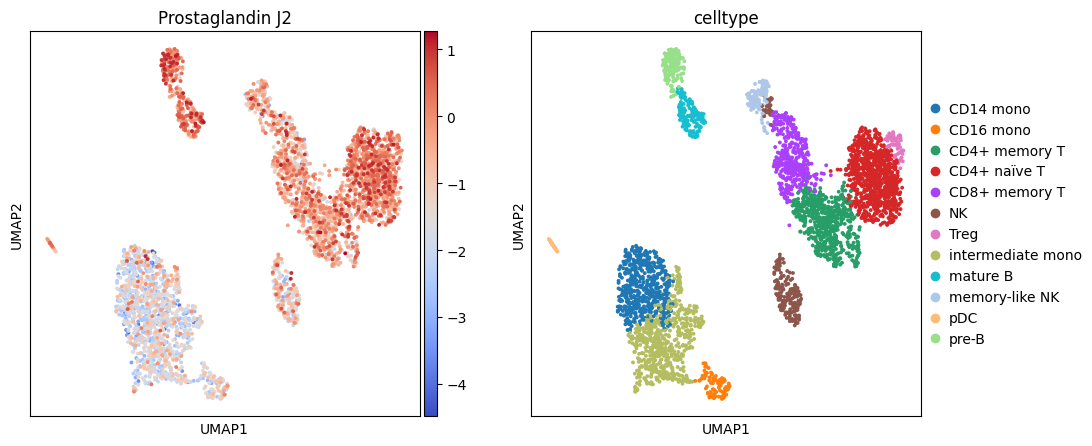

In [25]:
with plt.rc_context({"figure.figsize": (5, 5), "figure.dpi": (100)}):
    sc.pl.umap(meta.mod['metabolite'], color=['Prostaglandin J2', 'celltype'], cmap='coolwarm')
    

### Infer Metabolite-Receptor Interactions

We will next infer the putative ligand-receptor interactions between these two modalities.

In [27]:
li.mt.rank_aggregate(adata=meta,
                     groupby='celltype',
                     # pass our modified resource
                     resource=resource.rename(columns={'source':'ligand'}),
                     # NOTE: Essential arguments when handling multimodal data
                     mdata_kwargs={
                     'x_mod': 'metabolite',
                     'y_mod': 'receptor',
                     'x_use_raw':False,
                     'y_use_raw':False,
                     'x_transform':li.ut.zi_minmax,
                     'y_transform':li.ut.zi_minmax,
                    },
                  verbose=True
                  )


Using `.X`!
Converting to sparse csr matrix!


Using provided `resource`.
Transforming metabolite using zi_minmax


Using `.X`!
Using `.X`!
/Users/ef6/miniforge3/envs/sb26/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/Users/ef6/miniforge3/envs/sb26/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.47 of entities in the resource are missing from the data.


Transforming receptor using zi_minmax
Generating ligand-receptor stats for 3885 samples and 175 features


/Users/ef6/miniforge3/envs/sb26/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
/Users/ef6/miniforge3/envs/sb26/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
/Users/ef6/miniforge3/envs/sb26/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:293: FutureWarning: The method uns_keys is deprecated and will be removed in the future. Use uns instead of uns_keys. (e.g. `k in adata.uns` or `sorted(adata.uns)`)
/Users/ef6/miniforge3/envs/sb26/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:296: FutureWarning: The method uns_keys is deprecated and will be removed in the future. Use uns instead of uns_keys. (e.g. `k in adata.uns` or `sorted(adata.uns)`)


Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|██████████| 1000/1000 [00:01<00:00, 718.60it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


### Explore Results

In [28]:
meta.uns['liana_res'].head()

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
3203,pre-B,NK,Prostaglandin J2,PTGDR,0.498391,0.0,0.170128,1.251590,0.361967,0.069165,0.710418,0.001949,8.643495e-07
2368,mature B,NK,Prostaglandin J2,PTGDR,0.482969,0.0,0.163385,1.204872,0.341928,0.066424,0.706240,0.002367,3.456684e-06
1810,Treg,NK,Prostaglandin J2,PTGDR,0.472941,0.0,0.159000,1.174493,0.321560,0.064641,0.703410,0.002886,7.775931e-06
979,CD4+ naïve T,NK,Prostaglandin J2,PTGDR,0.461330,0.0,0.153923,1.139322,0.345939,0.062577,0.700014,0.003321,1.382102e-05
702,CD4+ memory T,NK,Prostaglandin J2,PTGDR,0.416395,0.0,0.134274,1.003198,0.259653,0.054589,0.685482,0.005002,1.043702e-04


/Users/ef6/miniforge3/envs/sb26/lib/python3.11/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


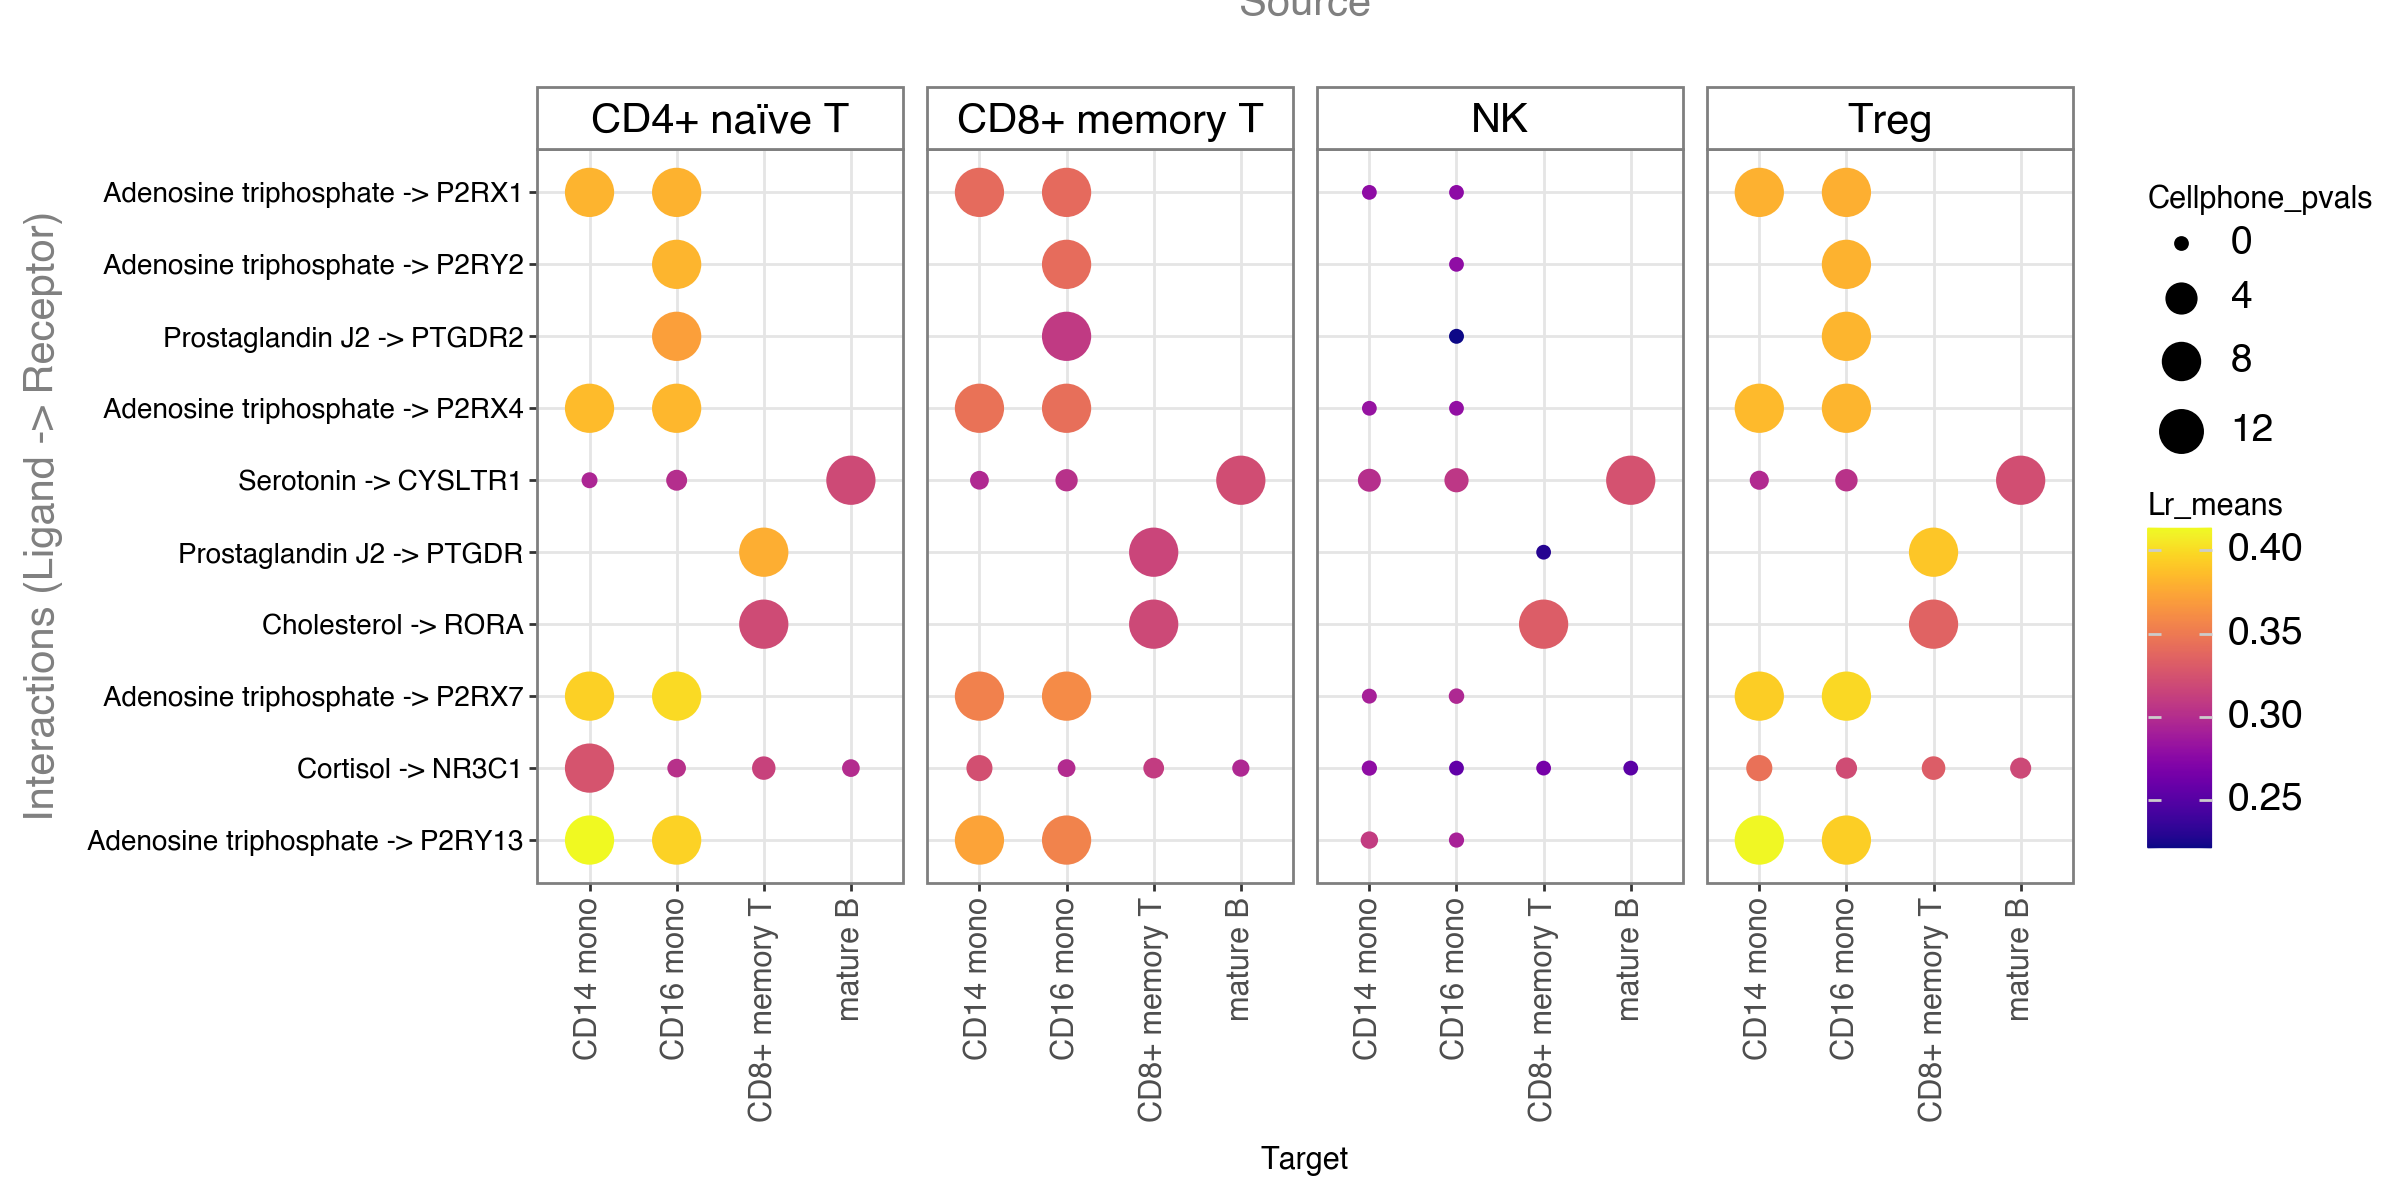

In [29]:
li.pl.dotplot(adata = meta,
              colour='lr_means',
              size='cellphone_pvals',
              inverse_size=True, # we inverse sign since we want small p-values to have large sizes
              source_labels=['CD4+ naïve T', 'NK', 'Treg', 'CD8+ memory T'],
              target_labels=['CD14 mono', 'mature B', 'CD8+ memory T', 'CD16 mono'],
              figure_size=(12, 6),
              # Filter to top 10 acc to magnitude rank
              top_n=10,
              orderby='magnitude_rank',
              orderby_ascending=True,
              cmap='plasma'
             )

<div class="alert alert-warning">
Our metabolite estimation approach, like other approaches predicting metabolite-receptor interactions from transcriptomics data, infers metabolite abundances from gene expression, assuming a linear relationship between enzymatic gene expression and metabolite abundance. Thereby, it overlooks the complex, non-linear nature of metabolite fluxes influenced by cell states and microenvironments. Finally, our method treats each metabolite independently - simplifications and limitations that [more sophisticated methods](https://www.sciencedirect.com/science/article/pii/S2212877821002532) or [multi-omics integration](https://liana-py.readthedocs.io/en/latest/notebooks/sma.html) may address. Thus, any inferred metabolite-protein interactions remain purely hypothetical and require validation.

</div>

## Next Steps
From here on one may follow-up with any of the other LIANA+ functionalities, such as plotting the results, or cross-conditional analyses.